103.4301408
103
96.96670344
96


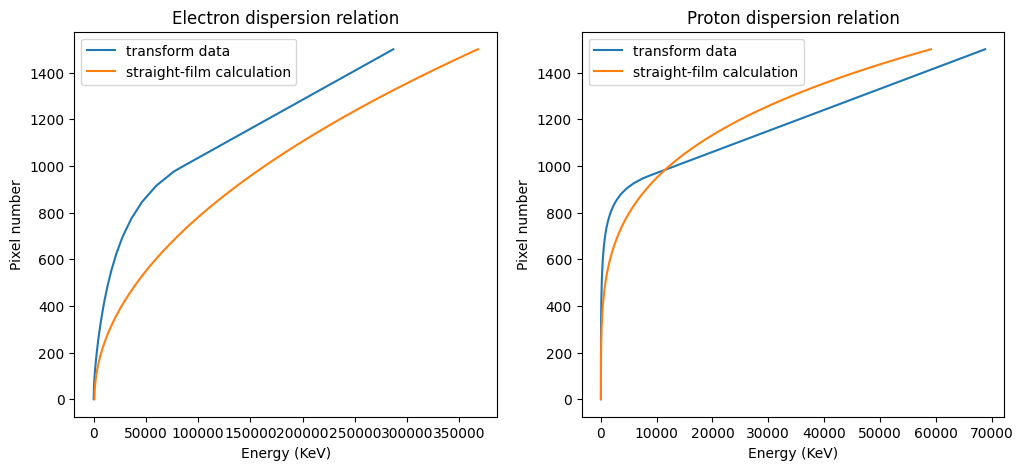

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

def lineout(array, w1, w2):
    width = np.shape(array)[0]
    length = np.shape(array)[1]
    line_data = array[w2,:]
    for i in range(length):
        line_data[i] = (1/(w2+1-w1))*np.sum(array[w1:w2+1,i])
    return line_data

def theoretical_dispersion(x,A,d):
    energy = A*(x**2+d**2)**2
    return energy

def theoretical_dispersion_relativistic_e(x,a,D):
    m = 9.1*10**-31
    c = 3*10**8
    E = m*c**2
    eV = 1.6*10**-19
    energy = (1/1000)*(1/eV)*0.5*(-E+np.sqrt(E**2+((eV*0.87*c)**2)*(1/D)*((((x-a)**2)+D)**2)))
    return energy

def theoretical_dispersion_relativistic_p(x,a,D):
    m = 1.67*10**-27
    c = 3*10**8
    E = m*c**2
    eV = 1.6*10**-19
    energy = (1/1000)*(1/eV)*0.5*(-E+np.sqrt(E**2+((eV*0.87*c)**2)*(1/D)*((((x-a)**2)+D)**2)))
    return energy

energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)

def linear_fit(x,m,c):
    y = m*x+c
    return y

def transform_electron_axis(x, R):
    energy = np.zeros(len(x))
    start = energy_data_electrons[-1,1]
    print(start)
    for i in range(len(x)):
        if np.abs((1/R)*x[i]-start) == np.min(np.abs((1/R)*x-start)):
            index = i
    print(index)
    energy[0:index] = np.interp((1/R)*x[0:index],np.array(energy_data_electrons[:,1]),np.array(energy_data_electrons[:,0]))

    deltax = energy_data_electrons[-1,1]-energy_data_electrons[-2,1]

    deltaE = energy_data_electrons[-1,0]-energy_data_electrons[-2,0]

    grad = deltaE/deltax

    intercept = energy_data_electrons[-1,0] - grad*energy_data_electrons[-1,1]

    energy[index:] = linear_fit((1/R)*x[index:], grad, intercept)

    return energy

def transform_proton_axis(x, R):
    energy = np.zeros(len(x))
    start = energy_data_protons[-1,1]
    print(start)
    for i in range(len(x)):
        if np.abs((1/R)*x[i]-start) == np.min(np.abs((1/R)*x-start)):
            index = i
    print(index)
    energy[0:index] = np.interp((1/R)*x[0:index],np.array(energy_data_protons[:,1]),np.array(energy_data_protons[:,0]))

    deltax = energy_data_protons[-1,1]-energy_data_protons[-2,1]

    deltaE = energy_data_protons[-1,0]-energy_data_protons[-2,0]

    grad = deltaE/deltax

    intercept = energy_data_protons[-1,0] - grad*energy_data_protons[-1,1]

    energy[index:] = linear_fit((1/R)*x[index:], grad, intercept)

    return energy

def find_index(axis,start,end):
    for i in range(len(axis)):
        if np.abs(axis[i]-start) == np.min(np.abs(axis-start)):
            start_i = i

    for i in range(len(axis)):
        if np.abs(axis[i]-end) == np.min(np.abs(axis-end)):
            end_i = i
    return start_i, end_i


r = 10

x_axis = np.linspace(0,1500,150)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(transform_electron_axis(x_axis,10),x_axis,label='transform data')
axs[0].plot(theoretical_dispersion_relativistic_e((1/10000)*x_axis,0.0,0.008**2),x_axis,label='straight-film calculation')
axs[0].set_xlabel("Energy (KeV)")
axs[0].set_ylabel("Pixel number")
axs[0].set_title("Electron dispersion relation")
axs[0].legend()

axs[1].plot(transform_proton_axis(x_axis,10),x_axis,label='transform data')
axs[1].plot(theoretical_dispersion_relativistic_p((1/10000)*x_axis,0.001,0.012**2),x_axis,label='straight-film calculation')
axs[1].set_xlabel("Energy (KeV)")
axs[1].set_ylabel("Pixel number")
axs[1].set_title("Proton dispersion relation")
axs[1].legend()

ther_, pcov_ = curve_fit(theoretical_dispersion, energy_data_electrons[:,1], energy_data_electrons[:,0], p0=[0.0028,5])

energy = theoretical_dispersion((1/10)*x_axis, ther_[0], ther_[1])

#axs[0].plot(energy,x_axis)

96.96670344
96
96.96670344
96
96.96670344
96
96.96670344
96


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_63854/2775410089.py:30: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)


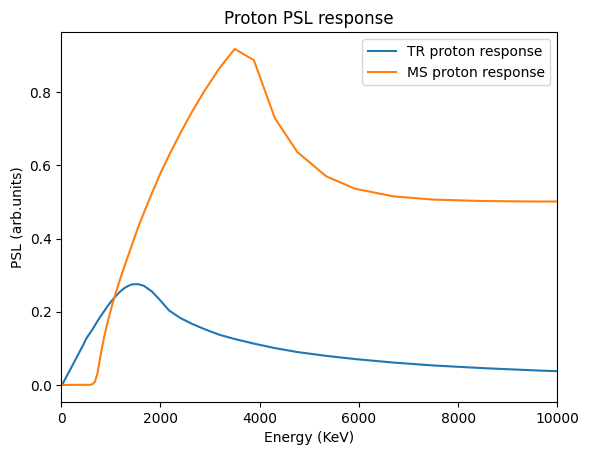

In [2]:
Proton_PSL_data = np.loadtxt('Proton_PSL_linylinx.txt', delimiter=',', skiprows=1)
Proton_PSL_data_low = np.loadtxt('Proton_PSL_low.txt', delimiter=',', skiprows=1)

TR_proton_energy_axis = 1000*Proton_PSL_data[:,0]
TR_proton_PSL_axis = Proton_PSL_data[:,1]

Proton_PSL_data = np.loadtxt('MS_Proton.txt', delimiter=',', skiprows=2)

MS_proton_energy_axis = 1000*Proton_PSL_data[:,0]
MS_proton_PSL_axis = Proton_PSL_data[:,1]

#plt.plot(TR_proton_energy_axis,TR_proton_PSL_axis)

#plt.plot(MS_proton_energy_axis,MS_proton_PSL_axis)

#plt.scatter(TR_proton_energy_axis,TR_proton_PSL_axis)

def find_exp_shift(E, A, a, shift):
    func = (A*np.exp(-a*E))+shift
    return func

def find_poly(E, A, a, shift):
    func = (A*E)**a+shift
    return func

def TR_proton_PSL_scale(Espace):
    PSL = np.interp(Espace,TR_proton_energy_axis,TR_proton_PSL_axis)
    return PSL

coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)

x = np.linspace(0,800,50)

poly_fit_MS = np.poly1d(coefficients)

#plt.plot(x,poly_fit_MS(x))

t_2, p_2 = curve_fit(find_exp_shift, np.linspace(4000,5000,100), np.interp(np.linspace(4000,5000,100),MS_proton_energy_axis,MS_proton_PSL_axis), p0=(1,0.0001,0.4))

fit_2 = find_exp_shift(np.linspace(4000,10000,100), t_2[0], t_2[1], t_2[2])

def MS_proton_PSL_scale(Espace):

    t_2, p_2 = curve_fit(find_exp_shift, np.linspace(4000,5000,100), np.interp(np.linspace(4000,5000,100),MS_proton_energy_axis,MS_proton_PSL_axis), p0=(1,0.0001,0.4))

    fit_2 = find_exp_shift(np.linspace(4000,10000,100), t_2[0], t_2[1], t_2[2])

    PSL = np.zeros(len(Espace))
    start = MS_proton_energy_axis[0]
    end = MS_proton_energy_axis[-1]
    
    for i in range(len(Espace)):
        if np.abs(Espace[i]-start) == np.min(np.abs(Espace-start)):
            start_index = i

    for i in range(len(Espace)):
        if np.abs(Espace[i]-end) == np.min(np.abs(Espace-end)):
            end_index = i

    PSL[start_index:end_index] = np.interp(Espace[start_index:end_index],MS_proton_energy_axis,MS_proton_PSL_axis)
    #PSL[:start_index] = MS_proton_PSL_axis[0]
    PSL[:start_index] = poly_fit_MS(Espace[:start_index])
    PSL[end_index:] = np.interp(Espace[end_index:],np.linspace(4000,10000,100),fit_2)

    return PSL

def find_exp(E, A, a):
    func = (A*np.exp(-a*E))
    return func

def find_2exp(E, A, a, B, b):
    func = func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))
    return func

def find_exp_proton(E, A, a, shift):
    func = (A*np.exp(-a*E))*TR_proton_PSL_scale(E)+shift
    return func

def find_2exp_proton(E, A, a, B, b, shift):
    func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))*TR_proton_PSL_scale(E)+shift
    return func

def find_temp(E, A, E0, kT):
    func = A*(1/np.sqrt(E))*np.exp((1/kT)*(np.sqrt(E)-np.sqrt(E0))**2)
    return func

##############################################################

energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)

def dxdE_electrons(x_in):
    x_d = np.array(energy_data_electrons[:,1])
    E_d = np.array(energy_data_electrons[:,0])
    dxde_data = np.gradient(x_d,E_d)
    dxde = np.interp(0.1*x_in,x_d,dxde_data)
    return dxde

def dxdE_protons(x_in):
    x_data = np.array(energy_data_protons[:,1])
    E_data = np.array(energy_data_protons[:,0])
    dxde_data = np.gradient(x_data,E_data)
    dxde = np.interp(0.1*x_in,x_data,dxde_data)
    return dxde

plt.plot(transform_proton_axis(x_axis,10), TR_proton_PSL_scale(transform_proton_axis(x_axis,10)), label = 'TR proton response')

plt.plot(transform_proton_axis(x_axis,10), MS_proton_PSL_scale(transform_proton_axis(x_axis,10)), label = 'MS proton response')

#plt.plot(np.linspace(4000,10000,100),find_exp_shift(np.linspace(4000,10000,100), t[0], t[1], t[2]))


#plt.plot(x, fit1)

plt.xlim(0,10000)
plt.xlabel("Energy (KeV)")
plt.ylabel("PSL (arb.units)")
plt.title("Proton PSL response")
plt.legend()

Text(0.5, 1.0, 'MS Electron PSL response')

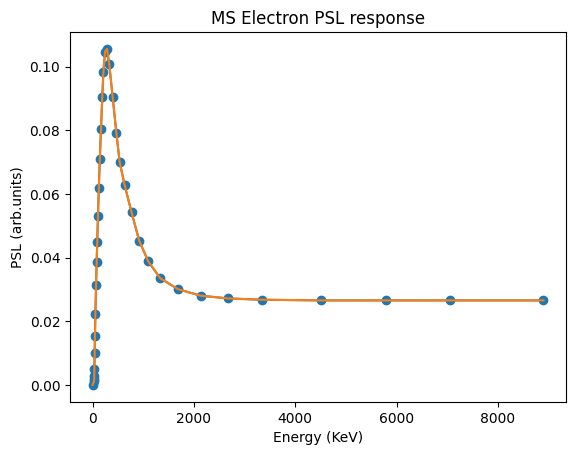

In [3]:
import numpy as np

MS_signal_data = np.loadtxt('MS_signal.txt', skiprows=1) # Adjust delimiter if needed
MS_energy_axis = 1000*MS_signal_data[:,0]
MS_PSL_axis = MS_signal_data[:,1]

plt.plot(MS_energy_axis,MS_PSL_axis)

def MS_PSL_scale(Espace):
    PSL = np.interp(Espace,MS_energy_axis,MS_PSL_axis)
    return PSL

def find_exp_electron(E, A, a, shift):
    func = (A*np.exp(-a*E))*MS_PSL_scale(E)+shift
    return func

def find_2exp_electron(E, A, a, B, b, shift):
    func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))*MS_PSL_scale(E)+shift
    return func

# Assuming your text file is named 'data.txt' and contains a 2D array
energy_data = np.loadtxt('Electron_Dispersion_Z_vs_Ebeam_0028T.txt', skiprows=8) # Adjust delimiter if needed

MS_signal_data = np.loadtxt('MS_signal.txt', skiprows=1) # Adjust delimiter if needed
MS_energy_axis = 1000*MS_signal_data[:,0]
MS_PSL_axis = MS_signal_data[:,1]

plt.plot(MS_energy_axis,MS_PSL_axis)
plt.scatter(MS_energy_axis,MS_PSL_axis)
plt.xlabel("Energy (KeV)")
plt.ylabel("PSL (arb.units)")
plt.title("MS Electron PSL response")
#plt.plot(transform_electron_axis(x_axis,10),MS_PSL_scale(transform_electron_axis(x_axis,10)))
#print(np.shape(energy_data[:,0]))
#print(np.shape(MS_energy_axis))
#plt.xlim([0,100000])
#print(np.shape(data))

100000.0
Temperature in keV =  100000.0
Bulk speed in c =  0


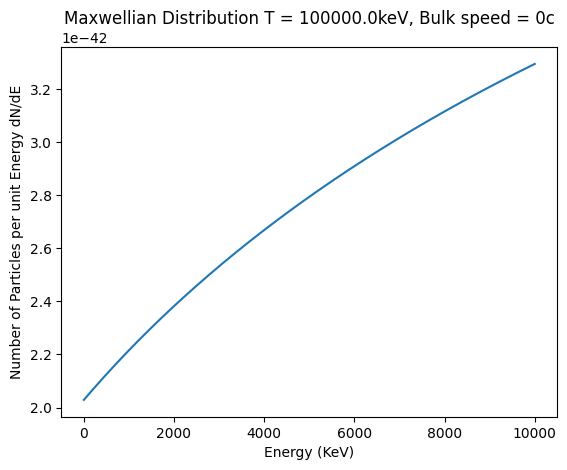

In [23]:
def p_(E):#E is in keV
    c = 299792458
    E_j = E*(1000*(1.602176e-19))
    #m = 9.11e-31
    m = 1.672621898e-27
    p = (1/c)*np.sqrt((E_j**2)-((m**2)*(c**4)))
    return p

def gamma(beta):
    gma = 1/(np.sqrt(1-(beta**2)))
    return gma

def Ep_prime(E,beta):
    c = 3e8
    E_j = E*1000*(1.602176e-19)
    #m = 9.11e-31
    m = 1.672621898e-27
    p = p_(E)
    gma = gamma(beta)
    E_prime = gma*(E_j-(beta*c*p))
    p_prime = gma*(p-((beta*E_j)/c))
    return E_prime, p_prime

def rel_maxwell(E, kT, beta, A):
    c = 3e8
    E_j = E*(1000*(1.602176e-19))
    #m = 9.11e-31
    m = 1.672621898e-27
    p = p_(E)
    gma = gamma(beta)
    E_prime, p_prime = Ep_prime(E,beta)
    #dist = np.exp(-(E_prime/(kT*1000*1.6e-19)))*gma*(1-((beta*p*c)/E_j))*(E_j/(p*c**2))
    dist = np.exp(-(E_prime/(kT*1000*1.602176e-19)))*gma*(E_j*p/c-((beta*p**2)))
    #area = np.trapz(dist,E)
    #dist_renormal = A*dist/area
    #return dist_renormal
    return dist

E = np.linspace(3,10000,200)
mass_energy = 1.6726e-27 * (299792458**2)

#Temp = 900
#Bulk_Speed = 0.05
#Amplitude = 4.5e6

#Temp = 300
#Bulk_Speed = 0.7
#Amplitude = 4.5e6

#Temp = 50
#Bulk_Speed = 0.7
#Amplitude = 1.0e6

#Temp = 50
Bulk_Speed = 0
T = 1e5
print(T)
Amplitude = 1.5e10

plt.plot(E,rel_maxwell(E+(mass_energy*1.005/(1000*(1.602176e-19))),T,Bulk_Speed,Amplitude))
#plt.ylim(-100,3000)
plt.xlabel("Energy (KeV)")
plt.ylabel("Number of Particles per unit Energy dN/dE")
plt.title('Maxwellian Distribution T = '+str(T)+'keV, Bulk speed = '+str(Bulk_Speed)+'c')

print('Temperature in keV = ', T)
print('Bulk speed in c = ', Bulk_Speed)

Temperature in keV =  380
Bulk speed in c =  0.7


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_63854/3364552633.py:6: RuntimeWarning: invalid value encountered in sqrt
  p = (1/c)*np.sqrt((E_j**2)-((m**2)*(c**4)))


(0.0, 10000.0)

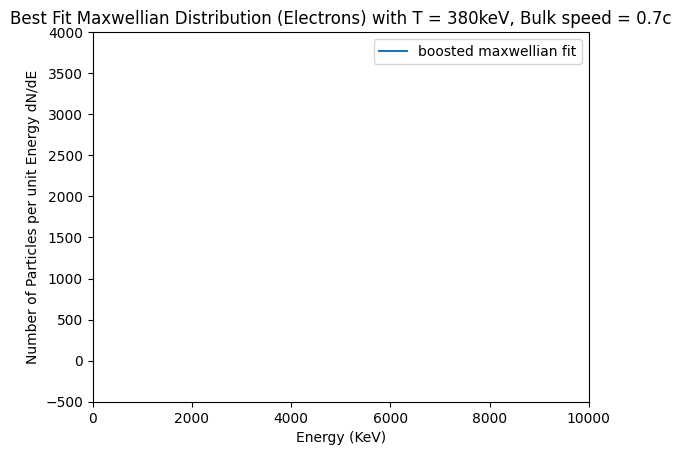

In [5]:
E_shift = E+938 #add the mass-energy of the electron

Temp = 380
Bulk_Speed = 0.7
Amplitude = 6.2e6

plt.plot(E,rel_maxwell(E_shift,Temp,Bulk_Speed,Amplitude), label = 'boosted maxwellian fit')
plt.ylim(-500,4000)
plt.xlim(0,20000)
plt.xlabel("Energy (KeV)")
plt.ylabel("Number of Particles per unit Energy dN/dE")
plt.title('Best Fit Maxwellian Distribution (Electrons) with T = '+str(Temp)+'keV, Bulk speed = '+str(Bulk_Speed)+'c')
plt.legend()
print('Temperature in keV = ', Temp)
print('Bulk speed in c = ', Bulk_Speed)

plt.xlim(0,10000)